In [1]:
import pandas as pd

data_path = 'data/porto-seguro-safe-driver-prediction/'

train = pd.read_csv(data_path + 'train.csv', index_col='id')
test = pd.read_csv(data_path + 'test.csv', index_col='id')
submission = pd.read_csv(data_path + 'sample_submission.csv', index_col='id')

In [2]:
train.shape, test.shape

((595212, 58), (892816, 57))

In [3]:
train.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


In [4]:
test.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
0,0,1,8,1,0,0,1,0,0,0,...,1,1,1,12,0,1,1,0,0,1
1,4,2,5,1,0,0,0,0,1,0,...,2,0,3,10,0,0,1,1,0,1
2,5,1,3,0,0,0,0,0,1,0,...,4,0,2,4,0,0,0,0,0,0
3,0,1,6,0,0,1,0,0,0,0,...,5,1,0,5,1,0,1,0,0,0
4,5,1,7,0,0,0,0,0,1,0,...,4,0,0,4,0,1,1,0,0,1


In [5]:
submission.head()

,target
id,
0,0.0364
1,0.0364
2,0.0364
3,0.0364
4,0.0364


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 595212 entries, 7 to 1488027
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          595212 non-null  int64  
 1   ps_ind_01       595212 non-null  int64  
 2   ps_ind_02_cat   595212 non-null  int64  
 3   ps_ind_03       595212 non-null  int64  
 4   ps_ind_04_cat   595212 non-null  int64  
 5   ps_ind_05_cat   595212 non-null  int64  
 6   ps_ind_06_bin   595212 non-null  int64  
 7   ps_ind_07_bin   595212 non-null  int64  
 8   ps_ind_08_bin   595212 non-null  int64  
 9   ps_ind_09_bin   595212 non-null  int64  
 10  ps_ind_10_bin   595212 non-null  int64  
 11  ps_ind_11_bin   595212 non-null  int64  
 12  ps_ind_12_bin   595212 non-null  int64  
 13  ps_ind_13_bin   595212 non-null  int64  
 14  ps_ind_14       595212 non-null  int64  
 15  ps_ind_15       595212 non-null  int64  
 16  ps_ind_16_bin   595212 non-null  int64  
 17  ps_ind_17_bin 

<Axes: >

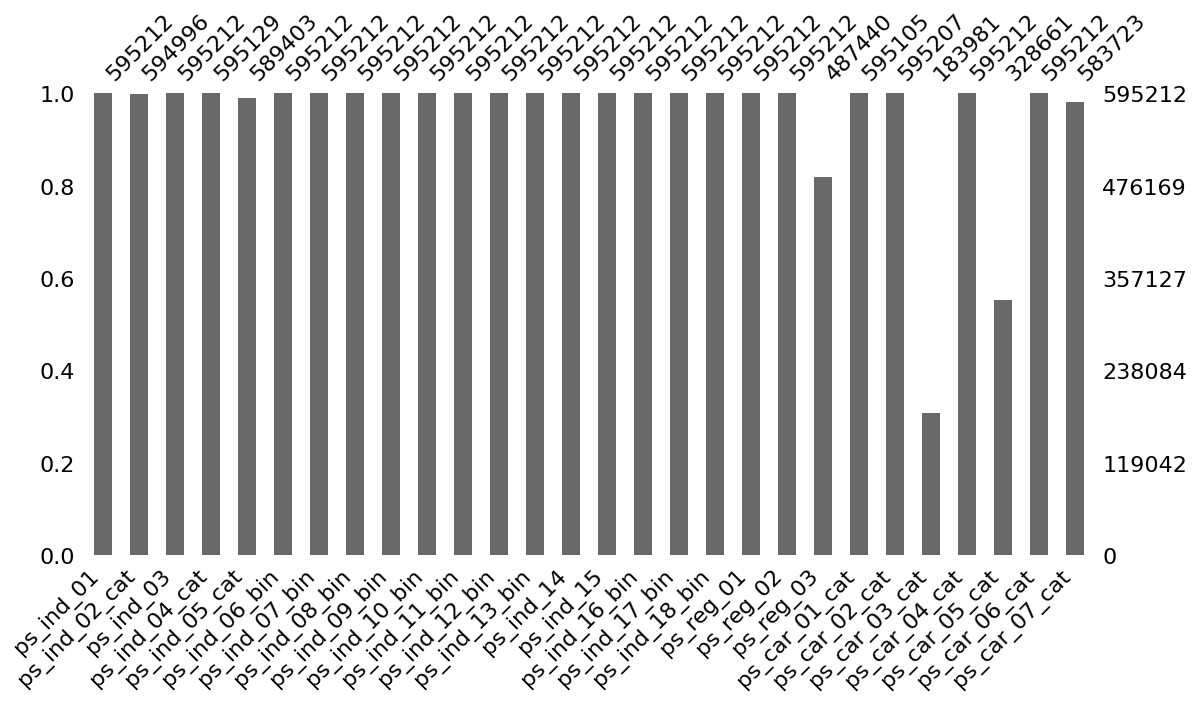

In [8]:
import numpy as np
import missingno as msno

train_copy = train.copy().replace(-1, np.nan)

msno.bar(df=train_copy.iloc[:, 1:29], figsize=(13, 6))

<Axes: >

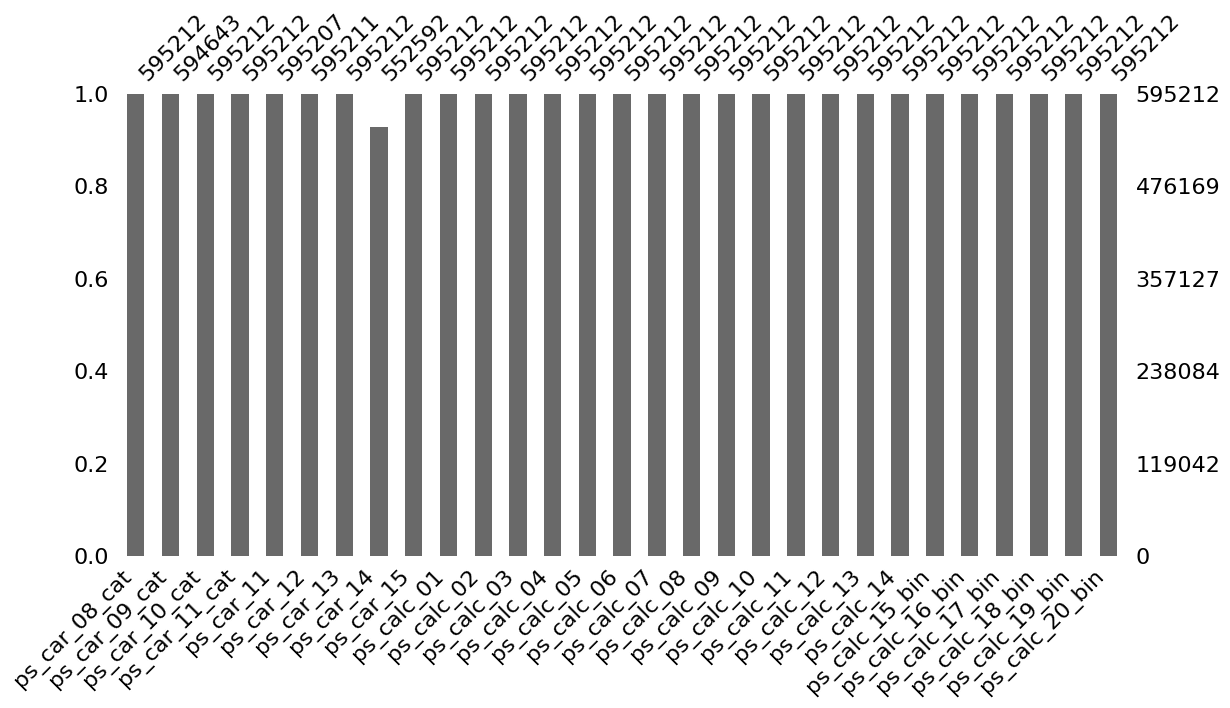

In [9]:
msno.bar(df=train_copy.iloc[:, 29:], figsize=(13, 6))

<Axes: >

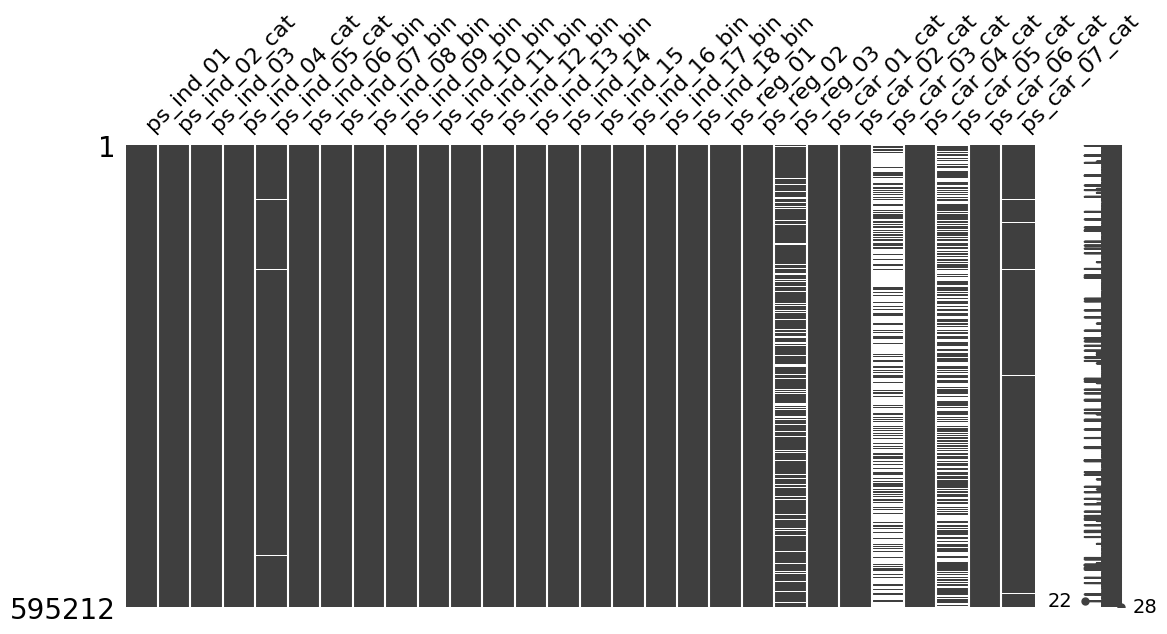

In [10]:
msno.matrix(df=train_copy.iloc[:, 1:29], figsize=(13, 6))

In [11]:
def resumetable(df):
  print(f'데이터셋 형상: {df.shape}')
  summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])
  summary['결측값 개수'] = (df == -1).sum().values
  summary['고윳값 개수'] = df.nunique().values
  summary['데이터 종류'] = None
  for col in df.columns:
    if 'bin' in col or col == 'target':
      summary.loc[col, '데이터 종류'] = '이진형'
    elif 'cat' in col:
      summary.loc[col, '데이터 종류'] = '명목형'
    elif df[col].dtype == np.float64:
      summary.loc[col, '데이터 종류'] = '연속형'
    elif df[col].dtype == np.int64:
      summary.loc[col, '데이터 종류'] = '순서형'

  return summary

In [12]:
summary = resumetable(train)
summary

데이터셋 형상: (595212, 58)


,데이터 타입,결측값 개수,고윳값 개수,데이터 종류
target,int64,0,2,이진형
ps_ind_01,int64,0,8,순서형
ps_ind_02_cat,int64,216,5,명목형
ps_ind_03,int64,0,12,순서형
ps_ind_04_cat,int64,83,3,명목형
ps_ind_05_cat,int64,5809,8,명목형
ps_ind_06_bin,int64,0,2,이진형
ps_ind_07_bin,int64,0,2,이진형
ps_ind_08_bin,int64,0,2,이진형
ps_ind_09_bin,int64,0,2,이진형


In [13]:
summary[summary['데이터 종류'] == '명목형'].index 

Index(['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat',
       'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat',
       'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat',
       'ps_car_10_cat', 'ps_car_11_cat'],
      dtype='object')

In [14]:
summary[summary['데이터 타입'] == 'float64'].index

Index(['ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_12', 'ps_car_13',
       'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03'],
      dtype='object')

In [15]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Target Distribution')

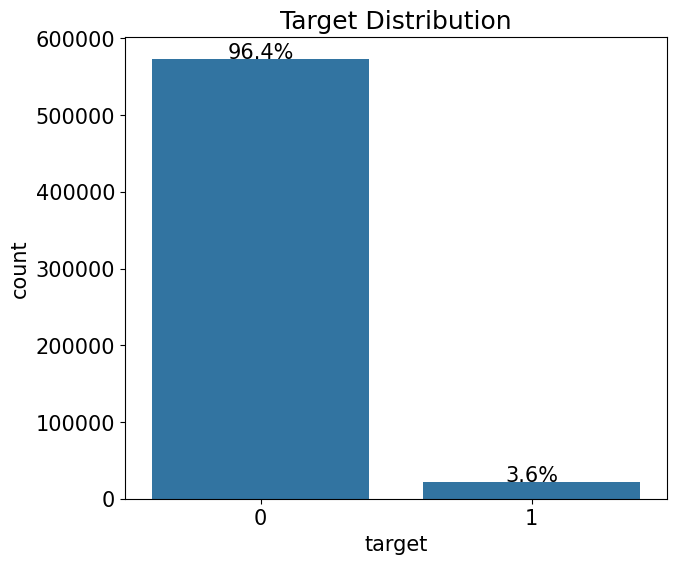

In [17]:
def write_percent(ax, total_size):
  '''도형 객체를 순회하며 막대 그래프 상단에 타깃값 비율 표시'''
  for patch in ax.patches:
    height = patch.get_height()
    width = patch.get_width()
    left_coord = patch.get_x()
    percent = height/total_size*100

    ax.text(left_coord + width/2.0, height+total_size*0.001, '{:1.1f}%'.format(percent), ha='center')

mpl.rc('font', size=15)
plt.figure(figsize=(7,6))

ax = sns.countplot(x='target', data=train)
write_percent(ax, len(train))
ax.set_title('Target Distribution')

In [18]:
import matplotlib.gridspec as gridspec

def plot_target_ratio_by_features(df, features, num_rows, num_cols, size=(12, 18)):
  mpl.rc('font', size=9)
  plt.figure(figsize=size)
  grid = gridspec.GridSpec(num_rows, num_cols)
  plt.subplots_adjust(wspace=0.3, hspace=0.3)

  for idx, feature in enumerate(features):
    ax = plt.subplot(grid[idx])
    sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)

<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

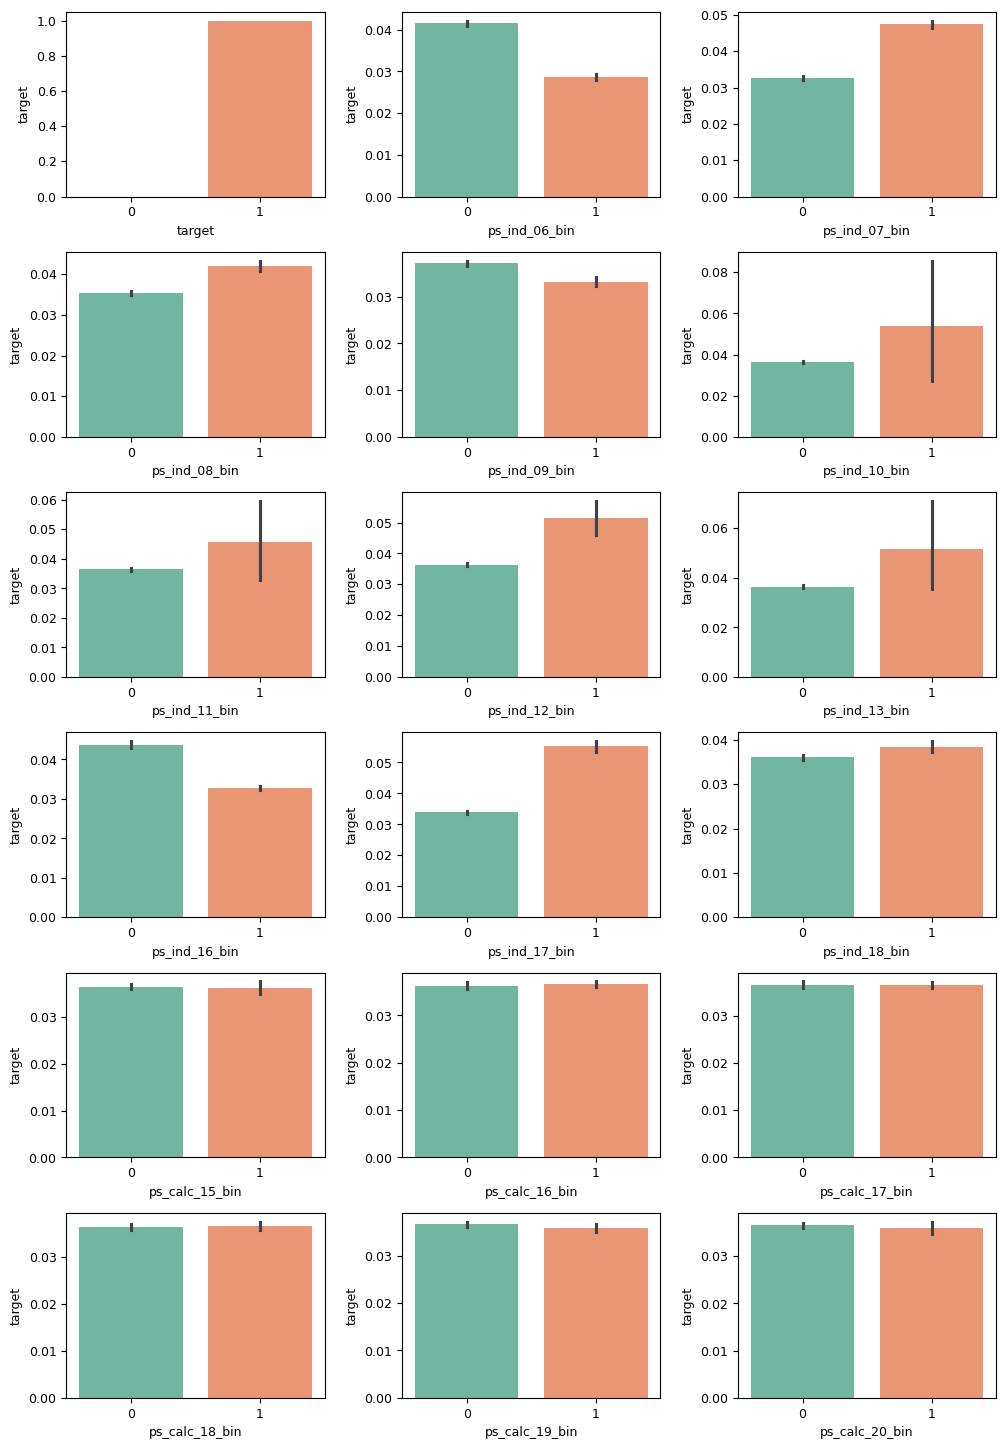

In [19]:
bin_features = summary[summary['데이터 종류'] == '이진형'].index

plot_target_ratio_by_features(train, bin_features, 6, 3)

<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

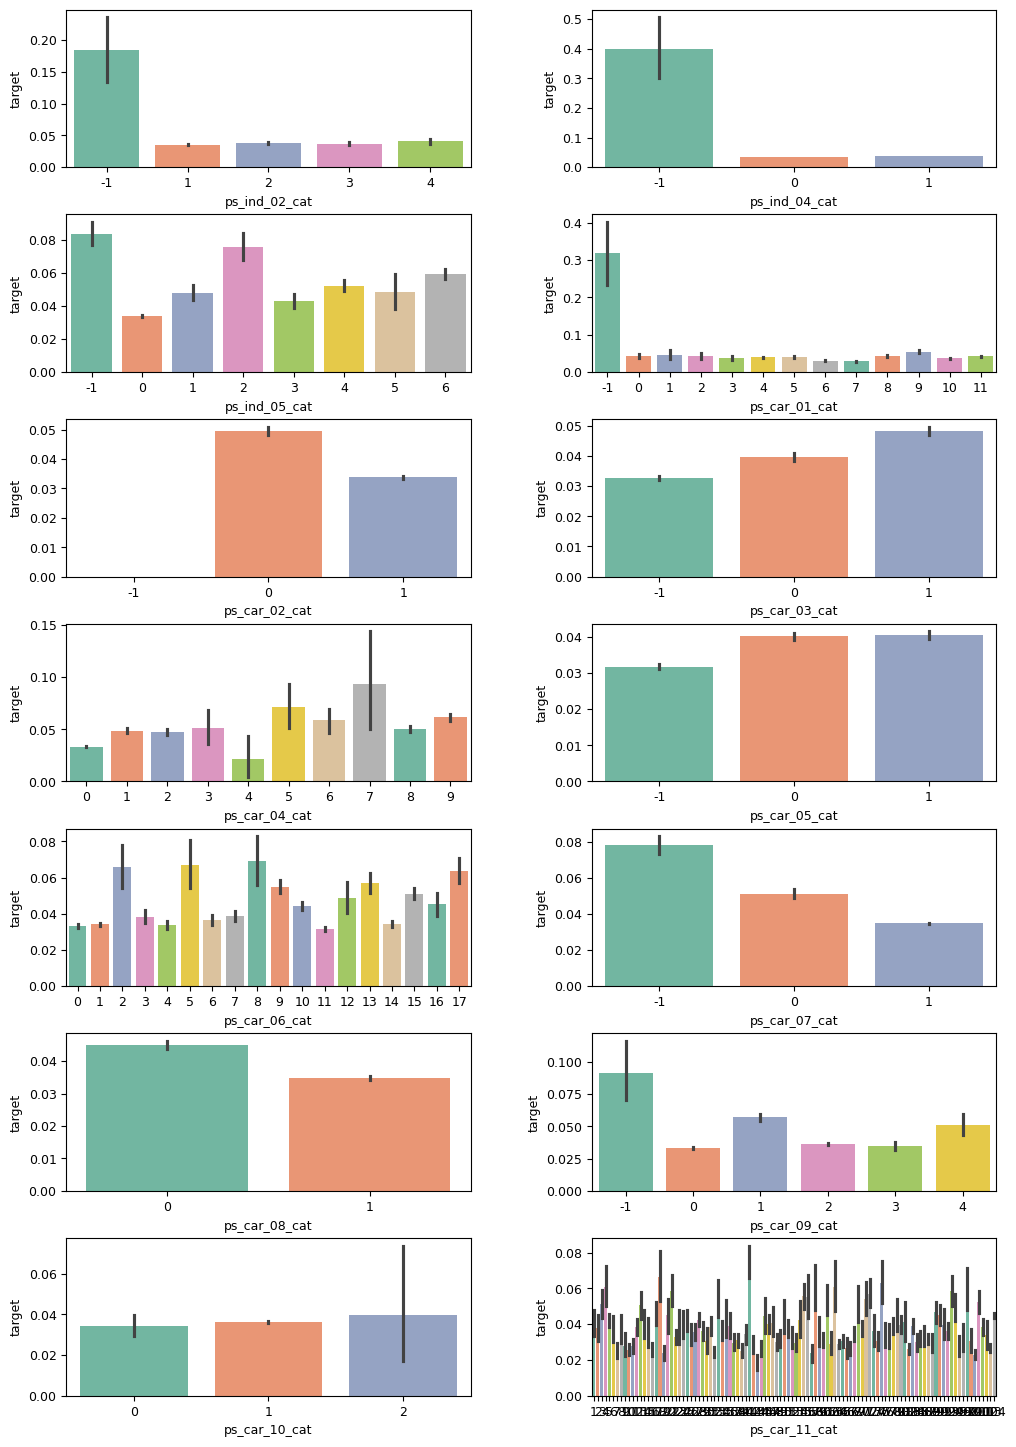

In [20]:
nom_features = summary[summary['데이터 종류'] == '명목형'].index

plot_target_ratio_by_features(train, nom_features, 7, 2)

<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='target', data=df, palette='Set2', ax=ax)
<ipython-input-18-ec1e768921e8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

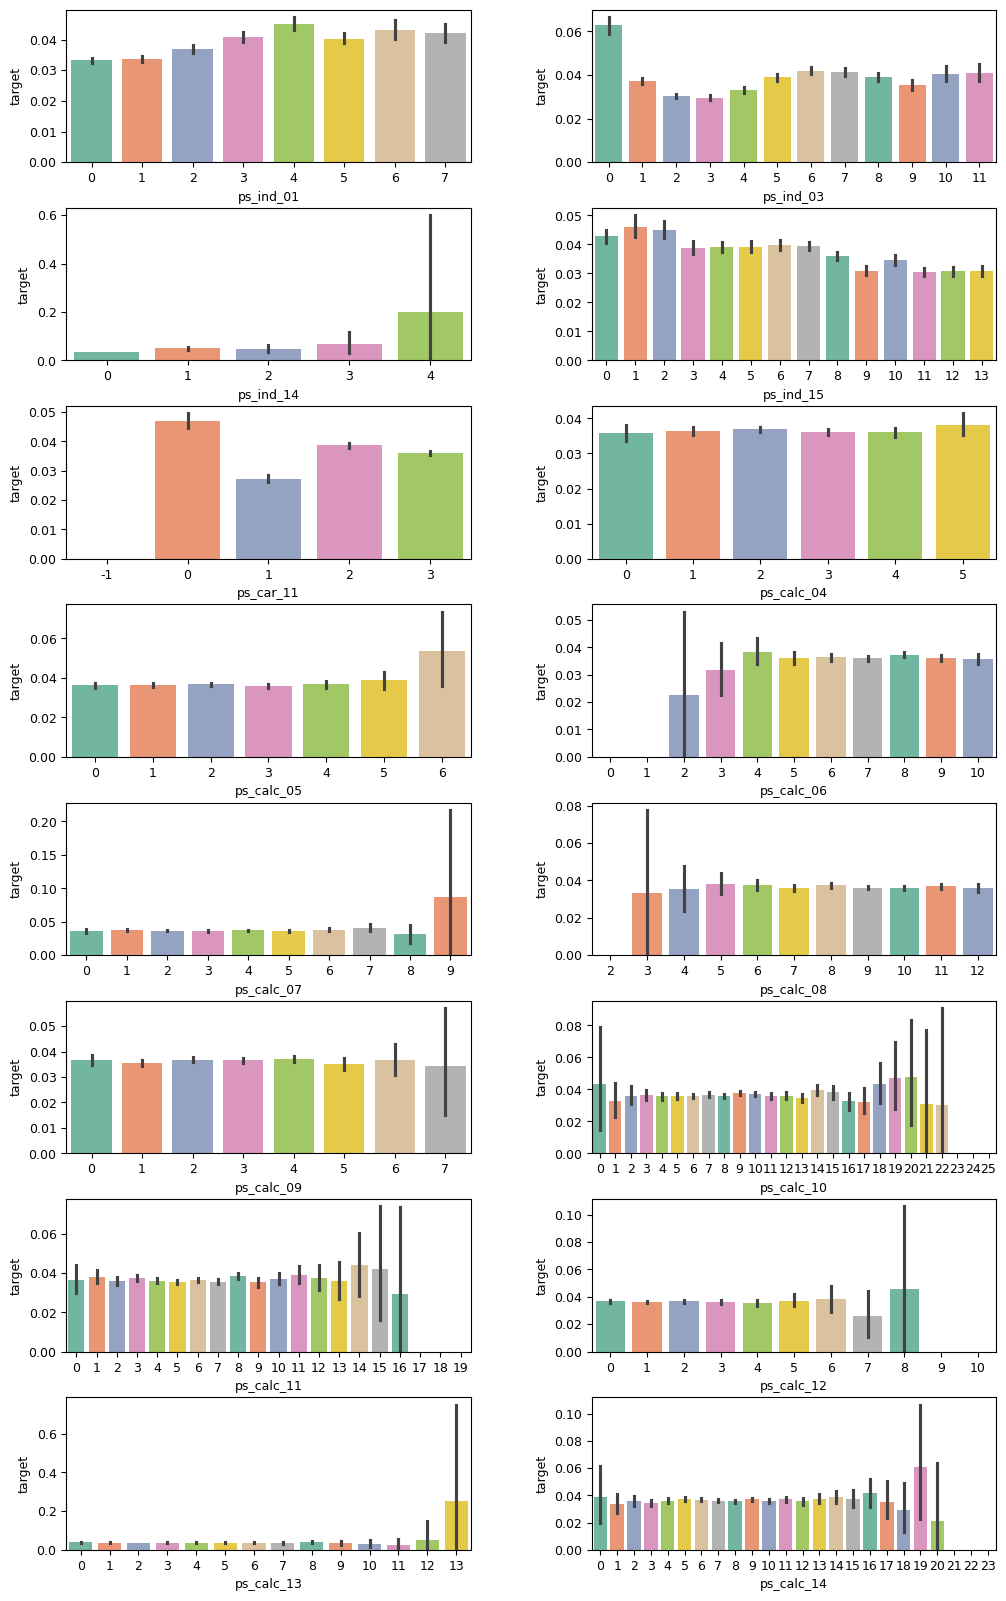

In [21]:
ord_features = summary[summary['데이터 종류'] == '순서형'].index

plot_target_ratio_by_features(train, ord_features, 8, 2, (12, 20))

In [22]:
pd.cut([1.0, 1.5, 2.1, 2.7, 3.5, 4.0], 3)

[(0.997, 2.0], (0.997, 2.0], (2.0, 3.0], (2.0, 3.0], (3.0, 4.0], (3.0, 4.0]]
Categories (3, interval[float64, right]): [(0.997, 2.0] < (2.0, 3.0] < (3.0, 4.0]]

<ipython-input-23-80bc86095328>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='target', data=train, palette='Set2', ax=ax)
<ipython-input-23-80bc86095328>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='target', data=train, palette='Set2', ax=ax)
<ipython-input-23-80bc86095328>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='target', data=train, palette='Set2', ax=ax)
<ipython-input-23-80bc86095328>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

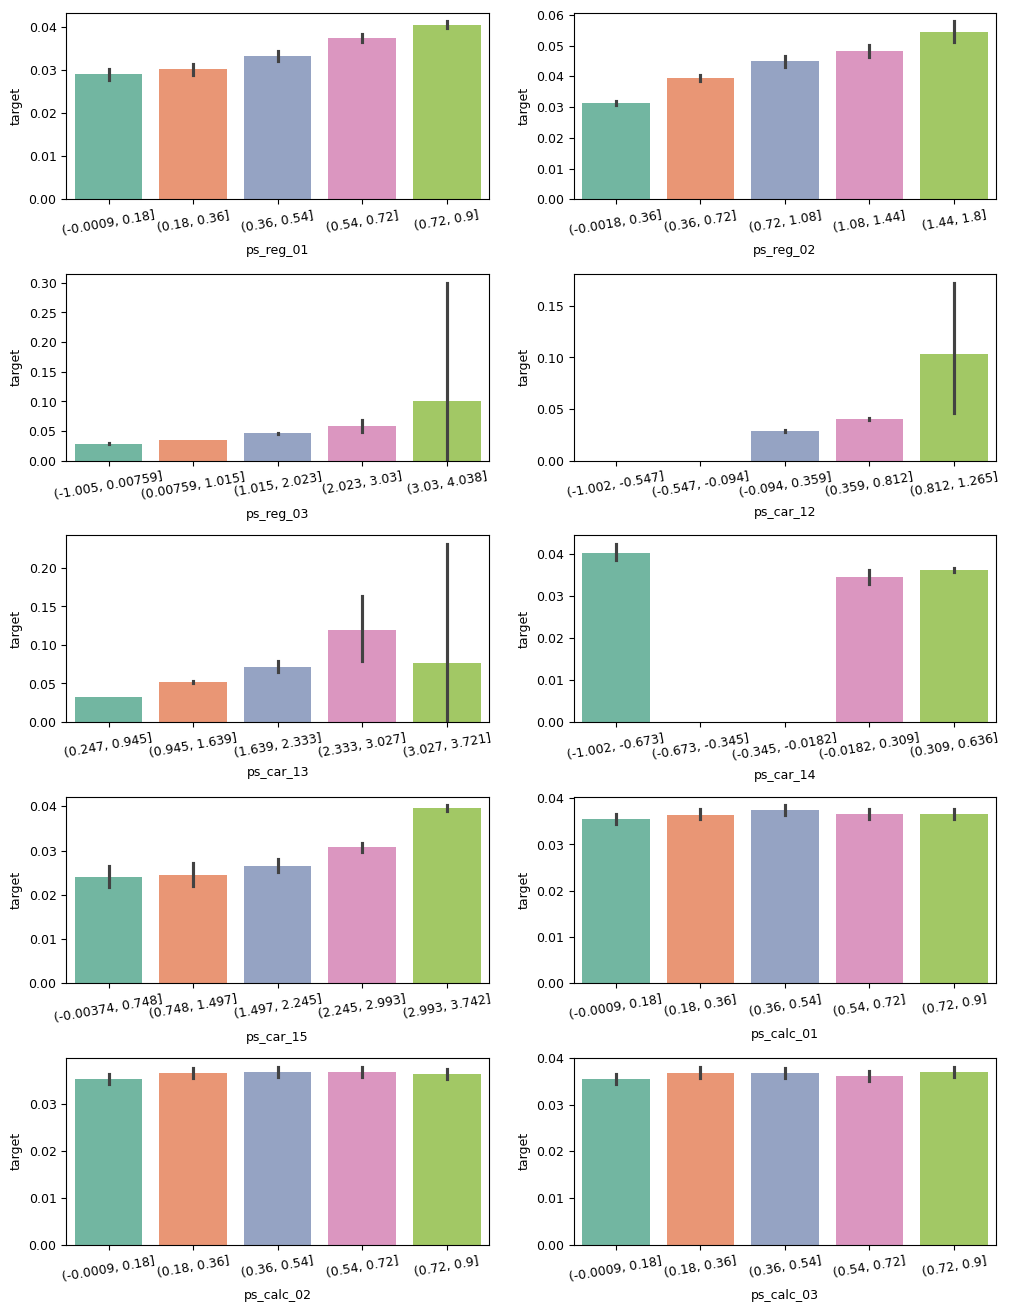

In [23]:
cont_features = summary[summary['데이터 종류'] == '연속형'].index

plt.figure(figsize=(12, 16))
grid = gridspec.GridSpec(5, 2)
plt.subplots_adjust(wspace=0.2, hspace=0.4)

for idx, cont_feature in enumerate(cont_features):
  train[cont_feature] = pd.cut(train[cont_feature], 5)

  ax = plt.subplot(grid[idx])
  sns.barplot(x=cont_feature, y='target', data=train, palette='Set2', ax=ax)
  ax.tick_params(axis='x', labelrotation=10)

In [24]:
train_copy = train_copy.dropna()

<Axes: >

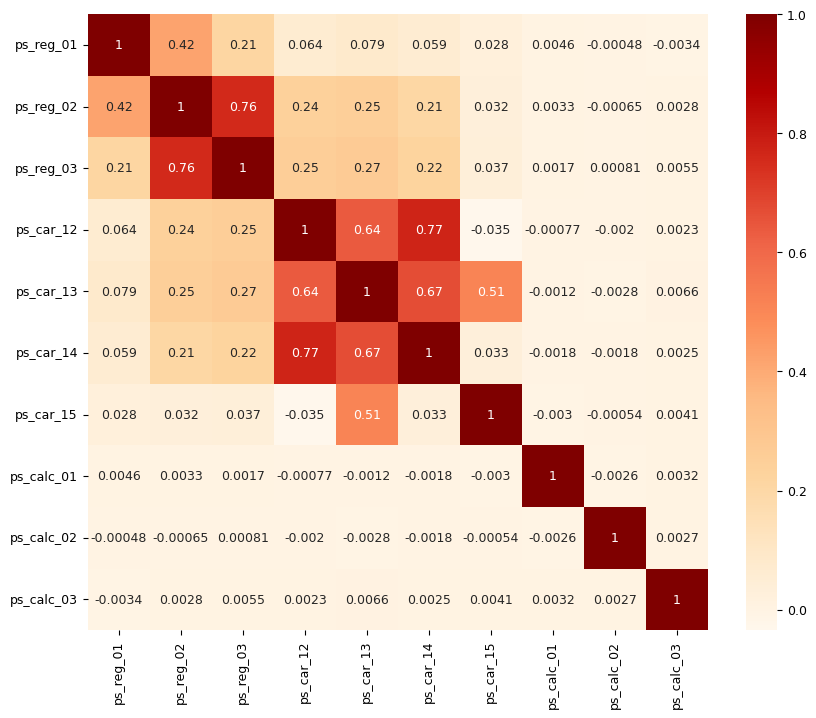

In [25]:
plt.figure(figsize=(10, 8))
cont_corr = train_copy[cont_features].corr()
sns.heatmap(cont_corr, annot=True, cmap='OrRd')

In [27]:
import pandas as pd

data_path = 'data/porto-seguro-safe-driver-prediction/'

train = pd.read_csv(data_path + 'train.csv', index_col='id')
test = pd.read_csv(data_path + 'test.csv', index_col='id')
submission = pd.read_csv(data_path + 'sample_submission.csv', index_col='id')

In [28]:
all_data = pd.concat([train, test], ignore_index=True)
all_data = all_data.drop('target', axis=1)

In [29]:
all_features = all_data.columns
all_features

Index(['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin'],
      dtype='obj

In [30]:
from sklearn.preprocessing import OneHotEncoder

cat_features = [feature for feature in all_features if 'cat' in feature]

onehot_encoder = OneHotEncoder()

encoded_cat_matrix = onehot_encoder.fit_transform(all_data[cat_features])

encoded_cat_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20832392 stored elements and shape (1488028, 184)>

In [31]:
drop_features = ['ps_ind_14', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_car_14']

remaining_features = [feature for feature in all_features if ('cat' not in feature and 'calc' not in feature and feature not in drop_features)]

In [32]:
from scipy import sparse

all_data_sprs = sparse.hstack([sparse.csr_matrix(all_data[remaining_features]), encoded_cat_matrix], format='csr')

In [33]:
num_train = len(train)

X = all_data_sprs[:num_train]
X_test = all_data_sprs[num_train:]

y = train['target'].values

In [34]:
import numpy as np

def eval_gini(y_true, y_pred):
  assert y_true.shape == y_pred.shape

  n_samples = y_true.shape[0]
  L_mid = np.linspace(1 / n_samples, 1, n_samples)
  
  pred_order = y_true[y_pred.argsort()]
  L_pred = np.cumsum(pred_order) / np.sum(pred_order)
  G_pred = np.sum(L_mid - L_pred)

  true_order = y_true[y_true.argsort()]
  L_true = np.cumsum(true_order) / np.sum(true_order)
  G_true = np.sum(L_mid - L_true)

  return G_pred / G_true

In [98]:
def gini(preds, dtrain):
  labels = dtrain.get_label()
  return 'gini', eval_gini(labels, preds), True

In [36]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=1991)

In [37]:
params = {'objective': 'binary', 'learning_rate': 0.01, 'force_row_wise': True, 'random_state': 0}

In [38]:
oof_val_preds = np.zeros(X.shape[0])

oof_test_preds = np.zeros(X_test.shape[0])

In [43]:
import lightgbm as lgb

for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
  print('#'*40, f'폴드 {idx + 1} / 폴드 {folds.n_splits}', '#'*40)

  X_train, y_train = X[train_idx], y[train_idx]
  X_valid, y_valid = X[valid_idx], y[valid_idx]

  dtrain = lgb.Dataset(X_train, y_train)
  dvalid = lgb.Dataset(X_valid, y_valid)

  lgb_model = lgb.train(params=params,
                        train_set=dtrain,
                        num_boost_round=1000,
                        valid_sets=dvalid,
                        feval=gini,
                        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)])
  
  oof_test_preds += lgb_model.predict(X_test)/folds.n_splits

  oof_val_preds[valid_idx] += lgb_model.predict(X_valid)

  gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
  print(f'폴드 {idx+1} 지니계수: {gini_score}\n')

######################################## 폴드 1 / 폴드 5 ########################################
[LightGBM] [Info] Number of positive: 17355, number of negative: 458814
[LightGBM] [Info] Total Bins 1095
[LightGBM] [Info] Number of data points in the train set: 476169, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274764
[LightGBM] [Info] Start training from score -3.274764
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.153354	valid_0's gini: 0.261652
[200]	valid_0's binary_logloss: 0.152426	valid_0's gini: 0.275704
[300]	valid_0's binary_logloss: 0.152023	valid_0's gini: 0.282277
[400]	valid_0's binary_logloss: 0.1518	valid_0's gini: 0.286648
[500]	valid_0's binary_logloss: 0.151713	valid_0's gini: 0.287944
[600]	valid_0's binary_logloss: 0.151672	valid_0's gini: 0.288637
[700]	valid_0's binary_logloss: 0.151659	valid_0's gini: 0.288939
Early stopping, best iteration is:
[681]	valid_0'

In [44]:
print('OOF 검증 데이터 지니계수:', eval_gini(y, oof_val_preds))

OOF 검증 데이터 지니계수: 0.28049957100553635


In [45]:
submission['target'] = oof_test_preds
submission.to_csv(data_path + 'submission.csv')

In [46]:
import pandas as pd

train = pd.read_csv(data_path + 'train.csv', index_col='id')
test = pd.read_csv(data_path + 'test.csv', index_col='id')
submission = pd.read_csv(data_path + 'sample_submission.csv', index_col='id')

In [47]:
all_data = pd.concat([train, test], ignore_index=True)
all_data = all_data.drop('target', axis=1)

all_features = all_data.columns

In [48]:
from sklearn.preprocessing import OneHotEncoder

cat_features = [feature for feature in all_features if 'cat' in feature]

onehot_encoder = OneHotEncoder()
encoded_cat_matrix = onehot_encoder.fit_transform(all_data[cat_features])

In [49]:
all_data['num_missing'] = (all_data==1).sum(axis=1)

In [50]:
remaining_features = [feature for feature in all_features if ('cat' not in feature and 'calc' not in feature)]

remaining_features.append('num_missing')

In [51]:
ind_features = [feature for feature in all_features if 'ind' in feature]

is_first_feature = True
for ind_feature in ind_features:
  if is_first_feature:
    all_data['mix_ind'] = all_data[ind_feature].astype(str) + '_'
    is_first_feature = False
  else:
    all_data['mix_ind'] += all_data[ind_feature].astype(str) + '_'

In [52]:
all_data['mix_ind']

0          2_2_5_1_0_0_1_0_0_0_0_0_0_0_11_0_1_0_
1           1_1_7_0_0_0_0_1_0_0_0_0_0_0_3_0_0_1_
2          5_4_9_1_0_0_0_1_0_0_0_0_0_0_12_1_0_0_
3           0_1_2_0_0_1_0_0_0_0_0_0_0_0_8_1_0_0_
4           0_2_0_1_0_1_0_0_0_0_0_0_0_0_9_1_0_0_
                           ...                  
1488023     0_1_6_0_0_0_1_0_0_0_0_0_0_0_2_0_0_1_
1488024    5_3_5_1_0_0_0_1_0_0_0_0_0_0_11_1_0_0_
1488025     0_1_5_0_0_1_0_0_0_0_0_0_0_0_5_0_0_1_
1488026    6_1_5_1_0_0_0_0_1_0_0_0_0_0_13_1_0_0_
1488027    7_1_4_1_0_0_0_0_1_0_0_0_0_0_12_1_0_0_
Name: mix_ind, Length: 1488028, dtype: object

In [53]:
all_data['ps_ind_02_cat'].value_counts()

ps_ind_02_cat
 1    1079327
 2     309747
 3      70172
 4      28259
-1        523
Name: count, dtype: int64

In [54]:
all_data['ps_ind_02_cat'].value_counts().to_dict()

{1: 1079327, 2: 309747, 3: 70172, 4: 28259, -1: 523}

In [55]:
cat_count_features = []
for feature in cat_features+['mix_ind']:
  val_counts_dict = all_data[feature].value_counts().to_dict()
  all_data[f'{feature}_count'] = all_data[feature].apply(lambda x: val_counts_dict[x])
  cat_count_features.append(f'{feature}_count')

In [56]:
cat_count_features

['ps_ind_02_cat_count',
 'ps_ind_04_cat_count',
 'ps_ind_05_cat_count',
 'ps_car_01_cat_count',
 'ps_car_02_cat_count',
 'ps_car_03_cat_count',
 'ps_car_04_cat_count',
 'ps_car_05_cat_count',
 'ps_car_06_cat_count',
 'ps_car_07_cat_count',
 'ps_car_08_cat_count',
 'ps_car_09_cat_count',
 'ps_car_10_cat_count',
 'ps_car_11_cat_count',
 'mix_ind_count']

In [57]:
from scipy import sparse

drop_features = ['ps_ind_14', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_car_14']

all_data_remaining = all_data[remaining_features+cat_count_features].drop(drop_features, axis=1)

all_data_sprs = sparse.hstack([sparse.csr_matrix(all_data_remaining), encoded_cat_matrix], format='csr')

In [58]:
all_data_remaining

,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,...,ps_car_03_cat_count,ps_car_04_cat_count,ps_car_05_cat_count,ps_car_06_cat_count,ps_car_07_cat_count,ps_car_08_cat_count,ps_car_09_cat_count,ps_car_10_cat_count,ps_car_11_cat_count,mix_ind_count
0,2,5,0,1,0,0,11,0,1,0,...,1028142,1241334,431560,77845,1383070,249663,486510,1475460,18326,6
1,1,7,0,0,1,0,3,0,0,1,...,1028142,1241334,666910,329890,1383070,1238365,883326,1475460,12535,36
2,5,9,0,0,1,0,12,1,0,0,...,1028142,1241334,666910,147714,1383070,1238365,883326,1475460,19943,24
3,0,2,1,0,0,0,8,1,0,0,...,183044,1241334,431560,329890,1383070,1238365,36798,1475460,212989,2784
4,0,0,1,0,0,0,9,1,0,0,...,1028142,1241334,666910,147714,1383070,1238365,883326,1475460,26161,258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488023,0,6,0,1,0,0,2,0,0,1,...,1028142,51211,389558,147714,76138,1238365,486510,1475460,3066,107
1488024,5,5,0,0,1,0,11,1,0,0,...,1028142,1241334,389558,83563,1383070,249663,486510,1475460,23506,26
1488025,0,5,1,0,0,0,5,0,0,1,...,1028142,1241334,666910,329890,1383070,249663,72947,1475460,9725,258
1488026,6,5,0,0,0,1,13,1,0,0,...,1028142,1241334,431560,83563,1383070,1238365,486510,1475460,31344,37


In [91]:
all_data_sprs

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 61437422 stored elements and shape (1488028, 217)>

In [92]:
num_train = len(train)

X = all_data_sprs[:num_train]
X_test = all_data_sprs[num_train:]

y = train['target'].values

In [93]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

bayes_dtrain = lgb.Dataset(X_train, y_train)
bayes_dvalid = lgb.Dataset(X_valid, y_valid)

In [94]:
param_bounds = {'num_leaves': (30, 40),
                'lambda_l1': (0.7, 0.9),
                'lambda_l2': (0.9, 1),
                'feature_fraction': (0.6, 0.7),
                'bagging_fraction': (0.6, 0.9),
                'min_child_samples': (6, 10),
                'min_child_weight': (10, 40)}

fixed_params = {'objective': 'binary',
                'learning_rate': 0.005,
                'bagging_freq': 1,
                'force_row_wise': True,
                'random_state': 1991}

In [99]:
def eval_function(num_leaves, lambda_l1, lambda_l2, feature_fraction, bagging_fraction, min_child_samples, min_child_weight):
  '''최적화하려는 평가지표(지니계수) 계산 함수'''

  params = {'num_leaves': int(round(num_leaves)),
            'lambda_l1': lambda_l1,
            'lambda_l2': lambda_l2,
            'feature_fraction': feature_fraction,
            'bagging_fraction': bagging_fraction,
            'min_child_samples': int(round(min_child_samples)),
            'min_child_weight': min_child_weight,
            'feature_pre_filter': False}
  params.update(fixed_params)

  print('하이퍼파라미터:', params)

  lgb_model = lgb.train(params=params,
                        train_set=bayes_dtrain,
                        num_boost_round=2500,
                        valid_sets=bayes_dvalid,
                        feval=gini,
                        callbacks=[lgb.early_stopping(stopping_rounds=300), lgb.log_evaluation(period=False)])

  preds = lgb_model.predict(X_valid)

  gini_score = eval_gini(y_valid, preds)
  print(f'지니계수 : {gini_score}\n')

  return gini_score

In [100]:
from bayes_opt import BayesianOptimization

optimizer = BayesianOptimization(f=eval_function, pbounds=param_bounds, random_state=0)

In [101]:
optimizer.maximize(init_points=3, n_iter=6)

|   iter    |  target   | baggin... | featur... | lambda_l1 | lambda_l2 | min_ch... | min_ch... | num_le... |
-------------------------------------------------------------------------------------------------------------
하이퍼파라미터: {'num_leaves': 34, 'lambda_l1': np.float64(0.8205526752143287), 'lambda_l2': np.float64(0.9544883182996897), 'feature_fraction': np.float64(0.6715189366372419), 'bagging_fraction': np.float64(0.7646440511781974), 'min_child_samples': 8, 'min_child_weight': np.float64(29.376823391999682), 'feature_pre_filter': False, 'objective': 'binary', 'learning_rate': 0.005, 'bagging_freq': 1, 'force_row_wise': True, 'random_state': 1991}
[LightGBM] [Info] Number of positive: 17383, number of negative: 458786
[LightGBM] [Info] Total Bins 1567
[LightGBM] [Info] Number of data points in the train set: 476169, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036506 -> initscore=-3.273091
[LightGBM] [Info] Start training from score -3.273091
Traini

KeyboardInterrupt: 

In [ ]:
max_params = optimizer.max['params']
max_params

{'bagging_fraction': np.float64(0.6213108174593661),
 'feature_fraction': np.float64(0.608712929970154),
 'lambda_l1': np.float64(0.7040436794880651),
 'lambda_l2': np.float64(0.9832619845547939),
 'min_child_samples': np.float64(9.112627003799401),
 'min_child_weight': np.float64(36.10036444740457),
 'num_leaves': np.float64(39.78618342232764)}

In [ ]:
max_params['num_leaves'] = int(round(max_params['num_leaves']))
max_params['min_child_samples'] = int(round(max_params['min_child_samples']))

In [ ]:
max_params.update(fixed_params)

In [ ]:
max_params

{'bagging_fraction': np.float64(0.6213108174593661),
 'feature_fraction': np.float64(0.608712929970154),
 'lambda_l1': np.float64(0.7040436794880651),
 'lambda_l2': np.float64(0.9832619845547939),
 'min_child_samples': 9,
 'min_child_weight': np.float64(36.10036444740457),
 'num_leaves': 40,
 'objective': 'binary',
 'learning_rate': 0.005,
 'bagging_freq': 1,
 'force_row_wise': True,
 'random_state': 1991}

In [70]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=1991)

oof_val_preds = np.zeros(X.shape[0])

oof_test_preds = np.zeros(X_test.shape[0])

for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
  print('#'*40, f'폴드 {idx+1} / 폴드 {folds.n_splits}', '#'*40)
  
  X_train, y_train = X[train_idx], y[train_idx]
  X_valid, y_valid = X[valid_idx], y[valid_idx]

  dtrain = lgb.Dataset(X_train, y_train)
  dvalid = lgb.Dataset(X_valid, y_valid)

  lgb_model = lgb.train(params=max_params,
                        train_set=dtrain,
                        num_boost_round=2500,
                        valid_sets=dvalid,
                        feval=gini,
                        callbacks=[lgb.early_stopping(stopping_rounds=300), lgb.log_evaluation(period=100)])
  
  oof_test_preds += lgb_model.predict(X_test) / folds.n_splits
  
  oof_val_preds[valid_idx] += lgb_model.predict(X_valid)

  gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
  print(f'폴드 {idx+1} 지니계수 : {gini_score}\n')

######################################## 폴드 1 / 폴드 5 ########################################
[LightGBM] [Info] Number of positive: 17355, number of negative: 458814
[LightGBM] [Info] Total Bins 1565
[LightGBM] [Info] Number of data points in the train set: 476169, number of used features: 216
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274764
[LightGBM] [Info] Start training from score -3.274764
Training until validation scores don't improve for 300 rounds
[100]	valid_0's binary_logloss: 0.154242	valid_0's gini: 0.270717
[200]	valid_0's binary_logloss: 0.153175	valid_0's gini: 0.276103
[300]	valid_0's binary_logloss: 0.152582	valid_0's gini: 0.279961
[400]	valid_0's binary_logloss: 0.152222	valid_0's gini: 0.283199
[500]	valid_0's binary_logloss: 0.151982	valid_0's gini: 0.286539
[600]	valid_0's binary_logloss: 0.151822	valid_0's gini: 0.289181
[700]	valid_0's binary_logloss: 0.151706	valid_0's gini: 0.291165
[800]	valid_0's binary_logloss: 0.151614	valid_

In [71]:
print('OOF 검증 데이터 지니계수 :', eval_gini(y, oof_val_preds))

OOF 검증 데이터 지니계수 : 0.28936281074404296


In [72]:
submission['target'] = oof_test_preds
submission.to_csv(data_path + 'submission_1.csv')

In [73]:
def gini(preds, dtrain):
  labels = dtrain.get_label()
  return 'gini', eval_gini(labels, preds)

In [74]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

bayes_dtrain = xgb.DMatrix(X_train, y_train)
bayes_dvalid = xgb.DMatrix(X_valid, y_valid)

In [75]:
param_bounds = {'max_depth': (4, 8),
                'subsample': (0.6, 0.9),
                'colsample_bytree': (0.7, 1.0),
                'min_child_weight': (5, 7),
                'gamma': (8, 11),
                'reg_alpha': (7, 9),
                'reg_lambda': (1.1, 1.5),
                'scale_pos_weight': (1.4, 1.6)}

fixed_params = {'objective': 'binary:logistic',
                'learning_rate': 0.02,
                'random_state': 1991}

In [78]:
def eval_function(max_depth, subsample, colsample_bytree, min_child_weight, reg_alpha, gamma, reg_lambda, scale_pos_weight):
  '''최적화하려는 평가지표(지니계수) 계산 함수'''
  params = {'max_depth': int(round(max_depth)),
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'min_child_weight': min_child_weight,
            'gamma': gamma,
            'reg_alpha': reg_alpha,
            'reg_lambda': reg_lambda,
            'scale_pos_weight': scale_pos_weight}
  params.update(fixed_params)

  print('하이퍼파라미터 :', params)

  xgb_model = xgb.train(params=params, 
                        dtrain=bayes_dtrain, 
                        num_boost_round=2000,
                        evals=[(bayes_dvalid, 'bayes_dvalid')],
                        maximize=True,
                        custom_metric=gini,
                        early_stopping_rounds=200,
                        verbose_eval=False)
  
  best_iter = xgb_model.best_iteration

  preds = xgb_model.predict(bayes_dvalid, iteration_range=(0, best_iter))

  gini_score = eval_gini(y_valid, preds)
  print(f'지니계수 : {gini_score}\n')

  return gini_score

In [79]:
from bayes_opt import BayesianOptimization

optimizer = BayesianOptimization(f=eval_function,
                                 pbounds=param_bounds,
                                 random_state=0)

optimizer.maximize(init_points=3, n_iter=6)

|   iter    |  target   | colsam... |   gamma   | max_depth | min_ch... | reg_alpha | reg_la... | scale_... | subsample |
-------------------------------------------------------------------------------------------------------------------------
하이퍼파라미터 : {'max_depth': 6, 'subsample': np.float64(0.867531900234624), 'colsample_bytree': np.float64(0.8646440511781974), 'min_child_weight': np.float64(6.0897663659937935), 'gamma': np.float64(10.14556809911726), 'reg_alpha': np.float64(7.84730959867781), 'reg_lambda': np.float64(1.3583576452266626), 'scale_pos_weight': np.float64(1.4875174422525386), 'objective': 'binary:logistic', 'learning_rate': 0.02, 'random_state': 1991}
지니계수 : 0.2770844916710198

| 1         | 0.2771    | 0.8646    | 10.15     | 6.411     | 6.09      | 7.847     | 1.358     | 1.488     | 0.8675    |
하이퍼파라미터 : {'max_depth': 7, 'subsample': np.float64(0.6261387899104622), 'colsample_bytree': np.float64(0.9890988281503088), 'min_child_weight': np.float64(6.0577898395058085)

In [80]:
max_params = optimizer.max['params']

In [81]:
max_params['max_depth'] = int(round(max_params['max_depth']))

max_params.update(fixed_params)
max_params

{'colsample_bytree': np.float64(1.0),
 'gamma': np.float64(8.124990400823425),
 'max_depth': 7,
 'min_child_weight': np.float64(5.0),
 'reg_alpha': np.float64(9.0),
 'reg_lambda': np.float64(1.5),
 'scale_pos_weight': np.float64(1.4),
 'subsample': np.float64(0.6),
 'objective': 'binary:logistic',
 'learning_rate': 0.02,
 'random_state': 1991}

In [83]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=1991)

oof_val_preds = np.zeros(X.shape[0])

oof_test_preds = np.zeros(X_test.shape[0])

for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
  print('#'*40, f'폴드 {idx+1} / 폴드 {folds.n_splits}', '#'*40)

  X_train, y_train = X[train_idx], y[train_idx]
  X_valid, y_valid = X[valid_idx], y[valid_idx]

  dtrain = xgb.DMatrix(X_train, y_train)
  dvalid = xgb.DMatrix(X_valid, y_valid)
  dtest = xgb.DMatrix(X_test)

  xgb_model = xgb.train(params=max_params,
                        dtrain=dtrain,
                        num_boost_round=2000,
                        evals=[(dvalid, 'valid')],
                        maximize=True,
                        custom_metric=gini,
                        early_stopping_rounds=200,
                        verbose_eval=100)
  
  best_iter = xgb_model.best_iteration
  
  oof_test_preds += xgb_model.predict(dtest, iteration_range=(0, best_iter))/folds.n_splits

  oof_val_preds[valid_idx] += xgb_model.predict(dvalid, iteration_range=(0, best_iter))

  gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
  print(f'폴드 {idx+1} 지니계수: {gini_score}\n')

######################################## 폴드 1 / 폴드 5 ########################################
[0]	valid-logloss:0.21709	valid-gini:0.20172
[100]	valid-logloss:0.15972	valid-gini:0.27379
[200]	valid-logloss:0.15461	valid-gini:0.28659
[300]	valid-logloss:0.15390	valid-gini:0.29184
[400]	valid-logloss:0.15375	valid-gini:0.29362
[500]	valid-logloss:0.15372	valid-gini:0.29420
[600]	valid-logloss:0.15370	valid-gini:0.29472
[700]	valid-logloss:0.15367	valid-gini:0.29502
[800]	valid-logloss:0.15368	valid-gini:0.29553
[900]	valid-logloss:0.15365	valid-gini:0.29582
[1000]	valid-logloss:0.15364	valid-gini:0.29585
[1100]	valid-logloss:0.15365	valid-gini:0.29596
[1200]	valid-logloss:0.15364	valid-gini:0.29617
[1300]	valid-logloss:0.15363	valid-gini:0.29624
[1400]	valid-logloss:0.15363	valid-gini:0.29639
[1500]	valid-logloss:0.15361	valid-gini:0.29661
[1600]	valid-logloss:0.15360	valid-gini:0.29663
[1700]	valid-logloss:0.15362	valid-gini:0.29680
[1800]	valid-logloss:0.15360	valid-gini:0.29700
[1900]

In [84]:
print('OOF 검증 데이터 지니계수 :', eval_gini(y, oof_val_preds))

OOF 검증 데이터 지니계수 : 0.28620031485462516


In [85]:
submission['target'] = oof_test_preds
submission.to_csv(data_path + 'submission_2.csv')

In [105]:
oof_test_preds_lgb = pd.read_csv(data_path + 'submission_1.csv', index_col='id')['target']
oof_test_preds_xgb = pd.read_csv(data_path + 'submission_2.csv', index_col='id')['target']

In [106]:
oof_test_preds = oof_test_preds_lgb * 0.5 + oof_test_preds_xgb * 0.5

In [109]:
submission['target'] = oof_test_preds
submission.to_csv(data_path + 'submission_3.csv')